In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

https://www.kaggle.com/datasets/noordeen/insurance-premium-prediction


Dataset for practice

In [2]:
df = pd.read_csv("Medicalpremium_nan.csv") # load data set
df.sample(10) # look the 10 random rows

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
901,19.0,1,0.0,0,0,150,72,0,0,0,15000
102,59.0,1,1.0,0,0,160,92,0,1,1,31000
267,30.0,1,1.0,0,1,182,91,0,0,1,23000
598,51.0,0,1.0,0,0,166,74,1,0,1,29000
299,35.0,0,1.0,0,0,168,87,1,0,0,23000
105,33.0,1,0.0,0,0,168,68,0,0,0,23000
732,50.0,1,0.0,0,0,177,100,0,0,0,35000
345,47.0,1,1.0,0,1,181,72,0,0,0,30000
236,35.0,0,1.0,0,0,161,93,0,0,0,23000
506,54.0,0,0.0,0,0,184,81,0,0,1,29000


# Perform Basic EDA

In [3]:
# check the number of rows and columns
print('Rows = ',df.shape[0], 'Columns = ',df.shape[1])

Rows =  986 Columns =  11


In [4]:
# Basic information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      975 non-null    float64
 1   Diabetes                 986 non-null    int64  
 2   BloodPressureProblems    974 non-null    float64
 3   AnyTransplants           986 non-null    int64  
 4   AnyChronicDiseases       986 non-null    int64  
 5   Height                   986 non-null    int64  
 6   Weight                   986 non-null    int64  
 7   KnownAllergies           986 non-null    int64  
 8   HistoryOfCancerInFamily  986 non-null    int64  
 9   NumberOfMajorSurgeries   986 non-null    int64  
 10  PremiumPrice             986 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 84.9 KB


In [5]:
# check the null values in dataset
df.isnull().sum()

Age                        11
Diabetes                    0
BloodPressureProblems      12
AnyTransplants              0
AnyChronicDiseases          0
Height                      0
Weight                      0
KnownAllergies              0
HistoryOfCancerInFamily     0
NumberOfMajorSurgeries      0
PremiumPrice                0
dtype: int64

In [6]:
# to check the duplicate values
df.duplicated().sum() # There is no duplicate value in my dataset

np.int64(0)

In [7]:
# check the all statisctical value of dataset
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,975.0,41.749744,14.041846,18.0,30.0,42.0,53.0,66.0
Diabetes,986.0,0.419878,0.493789,0.0,0.0,0.0,1.0,1.0
BloodPressureProblems,974.0,0.471253,0.499429,0.0,0.0,0.0,1.0,1.0
AnyTransplants,986.0,0.055781,0.229615,0.0,0.0,0.0,0.0,1.0
AnyChronicDiseases,986.0,0.180527,0.384821,0.0,0.0,0.0,0.0,1.0
Height,986.0,168.182556,10.098155,145.0,161.0,168.0,176.0,188.0
Weight,986.0,76.950304,14.265096,51.0,67.0,75.0,87.0,132.0
KnownAllergies,986.0,0.215010,0.411038,0.0,0.0,0.0,0.0,1.0
HistoryOfCancerInFamily,986.0,0.117647,0.322353,0.0,0.0,0.0,0.0,1.0
NumberOfMajorSurgeries,986.0,0.667343,0.749205,0.0,0.0,1.0,1.0,3.0


In [8]:
# Handling of nan value of age column

# To fill the nan value of age column
print('Mean Age  = ',df['Age'].mean())
print('Mode Age  = ',df['Age'].mode())
print('STD Age  = ',df['Age'].std())

Mean Age  =  41.74974358974359
Mode Age  =  0    43.0
Name: Age, dtype: float64
STD Age  =  14.041846283856085


In [9]:
# We will fill the age with mean age i.e. 42 (round up of 41.75)
df['Age'] = df['Age'].fillna(42)
df.isnull().sum()

Age                         0
Diabetes                    0
BloodPressureProblems      12
AnyTransplants              0
AnyChronicDiseases          0
Height                      0
Weight                      0
KnownAllergies              0
HistoryOfCancerInFamily     0
NumberOfMajorSurgeries      0
PremiumPrice                0
dtype: int64

In [10]:
# Handling of nan values of BloodPressureProblems colunm
# To fill the nan value of age column
print('Mean BloodPressureProblems  = ',df['BloodPressureProblems'].mean())
print('Mode BloodPressureProblems  = ',df['BloodPressureProblems'].mode())
print('STD BloodPressureProblems  = ',df['BloodPressureProblems'].std())



Mean BloodPressureProblems  =  0.47125256673511295
Mode BloodPressureProblems  =  0    0.0
Name: BloodPressureProblems, dtype: float64
STD BloodPressureProblems  =  0.4994293473962874


In [11]:
df['BloodPressureProblems'] = df['BloodPressureProblems'].fillna(0)
df.isnull().sum()

Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64

In [12]:
df['Age'].value_counts()

Age
42.0    34
43.0    30
27.0    27
35.0    26
45.0    25
59.0    25
44.0    24
25.0    24
48.0    24
66.0    23
46.0    23
18.0    23
33.0    23
49.0    23
32.0    22
29.0    22
47.0    22
64.0    22
30.0    22
24.0    22
19.0    21
62.0    21
21.0    21
31.0    20
51.0    20
50.0    20
54.0    20
22.0    19
40.0    19
36.0    19
63.0    19
52.0    19
37.0    18
34.0    18
38.0    17
65.0    17
20.0    17
55.0    17
53.0    17
60.0    17
28.0    17
61.0    16
58.0    16
56.0    15
23.0    13
26.0    13
57.0    12
39.0    11
41.0    11
Name: count, dtype: int64

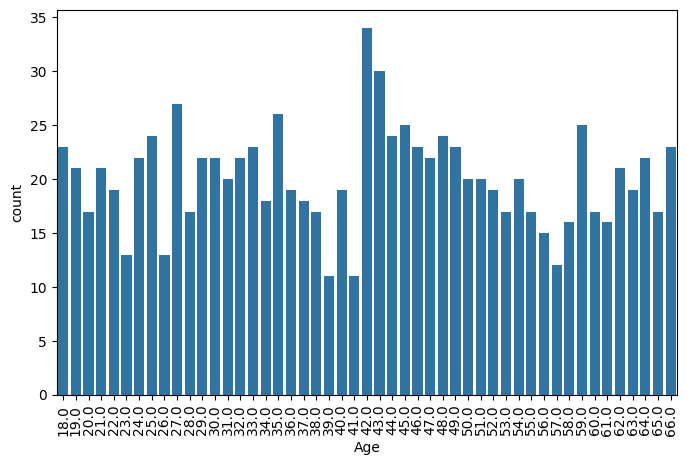

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x = df['Age'])
plt.xticks(rotation = 90)
plt.show()

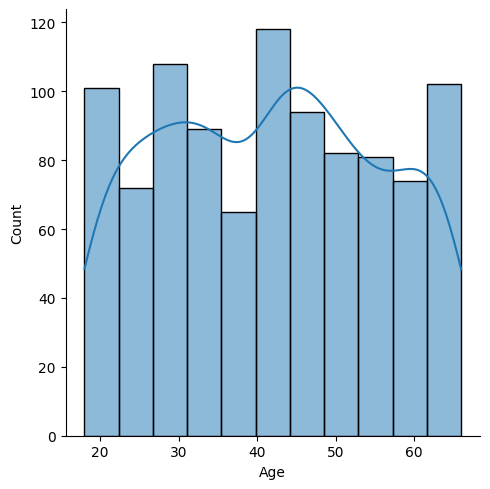

In [14]:
sns.displot(df['Age'], kde = True)

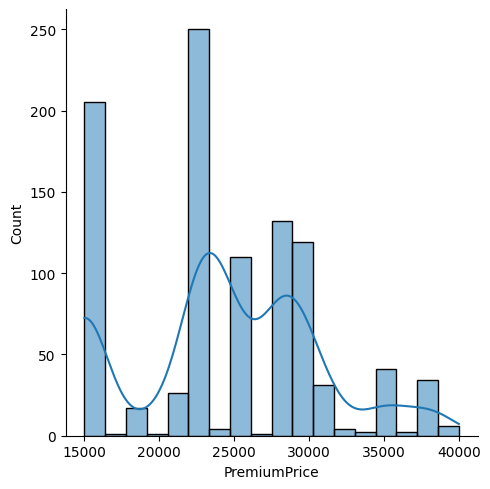

In [15]:
sns.displot(df['PremiumPrice'], kde = True)

<Axes: ylabel='PremiumPrice'>

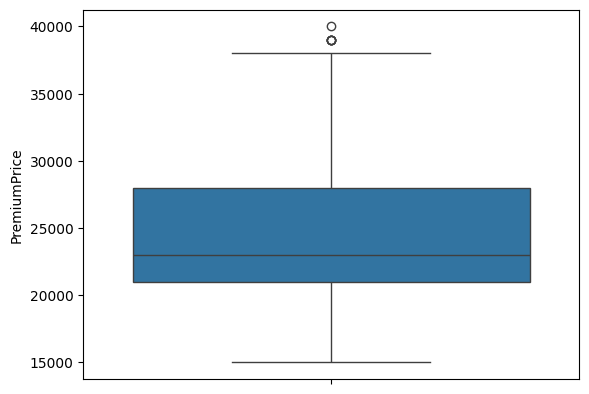

In [16]:
sns.boxplot(df['PremiumPrice'])

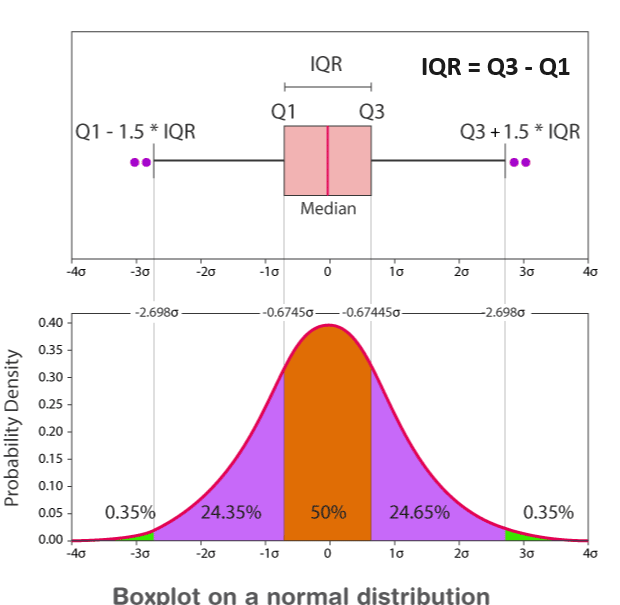

<Axes: ylabel='Weight'>

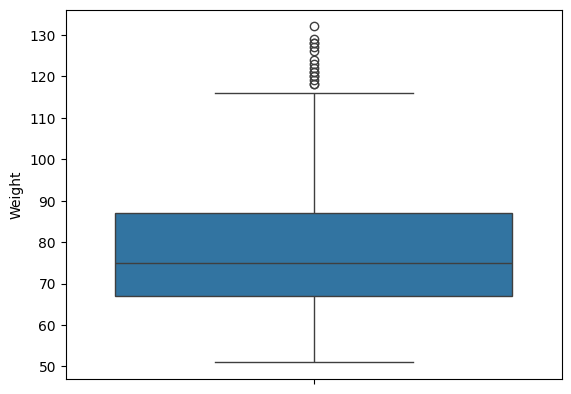

In [17]:
sns.boxplot(df['Weight'])

In [18]:
df['Weight'].describe()

count    986.000000
mean      76.950304
std       14.265096
min       51.000000
25%       67.000000
50%       75.000000
75%       87.000000
max      132.000000
Name: Weight, dtype: float64

In [19]:
q1 = 67
q3 = 87
IQR = q3-q1
IQR = 87-67
IQR

20

In [20]:
# lower_outlier = q1-(1.5*IQR)
# upper_outlier = q3+(1.5*IQR)
lower_outlier = 67-(1.5*20)
lower_outlier

37.0

In [21]:
# lower_outlier = q1-(1.5*IQR)
# upper_outlier = q3+(1.5*IQR)
lower_outlier = 87+(1.5*20)
lower_outlier

117.0

In [22]:
df[df['Weight']>117].count()

Age                        16
Diabetes                   16
BloodPressureProblems      16
AnyTransplants             16
AnyChronicDiseases         16
Height                     16
Weight                     16
KnownAllergies             16
HistoryOfCancerInFamily    16
NumberOfMajorSurgeries     16
PremiumPrice               16
dtype: int64

In [23]:
df[df['Weight']<37].count()

Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64

# Base question is - What will be the premium amount on the basis of given features

In [24]:
# Basic EDA
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,986.0,41.752535,13.963245,18.0,30.0,42.0,53.0,66.0
Diabetes,986.0,0.419878,0.493789,0.0,0.0,0.0,1.0,1.0
BloodPressureProblems,986.0,0.465517,0.499063,0.0,0.0,0.0,1.0,1.0
AnyTransplants,986.0,0.055781,0.229615,0.0,0.0,0.0,0.0,1.0
AnyChronicDiseases,986.0,0.180527,0.384821,0.0,0.0,0.0,0.0,1.0
Height,986.0,168.182556,10.098155,145.0,161.0,168.0,176.0,188.0
Weight,986.0,76.950304,14.265096,51.0,67.0,75.0,87.0,132.0
KnownAllergies,986.0,0.215010,0.411038,0.0,0.0,0.0,0.0,1.0
HistoryOfCancerInFamily,986.0,0.117647,0.322353,0.0,0.0,0.0,0.0,1.0
NumberOfMajorSurgeries,986.0,0.667343,0.749205,0.0,0.0,1.0,1.0,3.0


In [25]:
# 1. Diabetes, BP, Transplant, Chronic Diseases, Allergy, History of Cancer are Binary Values (0,1)

In [26]:
# Now find the correlation between features
df.corr()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
Age,1.000000,0.210919,0.242655,-0.008673,0.051400,0.039928,-0.018742,-0.024682,-0.027809,0.428829,0.697682
Diabetes,0.210919,1.000000,0.128848,-0.036652,-0.089428,-0.003783,-0.024563,-0.080102,-0.055527,0.122722,0.076209
BloodPressureProblems,0.242655,0.128848,1.000000,-0.031925,0.043019,-0.035011,-0.060349,-0.013311,0.050485,0.248959,0.168795
AnyTransplants,-0.008673,-0.036652,-0.031925,1.000000,0.035285,-0.031543,0.002087,0.001876,-0.020171,-0.004154,0.289056
AnyChronicDiseases,0.051400,-0.089428,0.043019,0.035285,1.000000,0.047419,-0.033318,-0.027418,0.008666,0.014835,0.208610
Height,0.039928,-0.003783,-0.035011,-0.031543,0.047419,1.000000,0.066946,-0.010200,0.010549,0.037289,0.026910
Weight,-0.018742,-0.024563,-0.060349,0.002087,-0.033318,0.066946,1.000000,0.037492,0.003481,-0.006108,0.141507
KnownAllergies,-0.024682,-0.080102,-0.013311,0.001876,-0.027418,-0.010200,0.037492,1.000000,0.115383,0.103923,0.012103
HistoryOfCancerInFamily,-0.027809,-0.055527,0.050485,-0.020171,0.008666,0.010549,0.003481,0.115383,1.000000,0.212657,0.083139
NumberOfMajorSurgeries,0.428829,0.122722,0.248959,-0.004154,0.014835,0.037289,-0.006108,0.103923,0.212657,1.000000,0.264250


<Axes: >

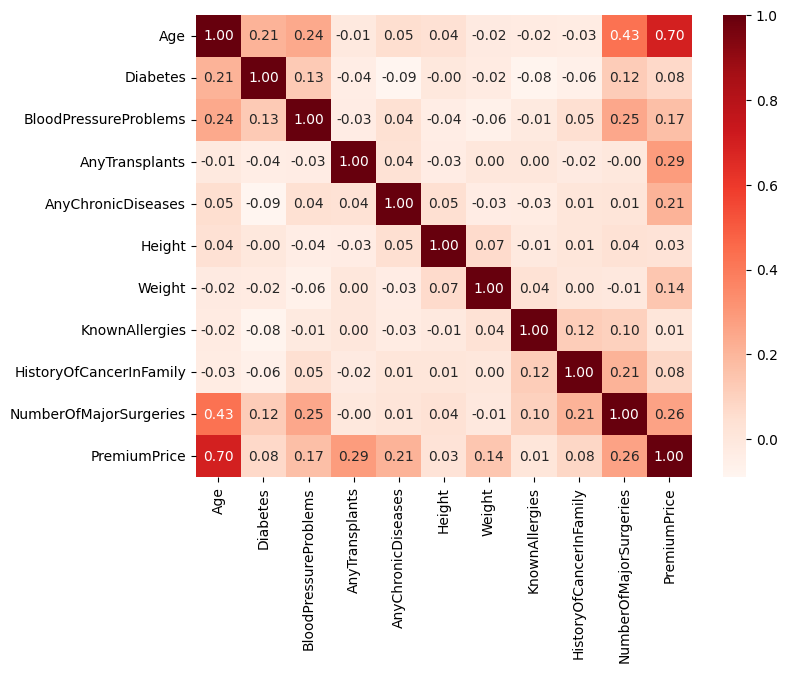

In [27]:
plt.figure(figsize = (8, 6))
sns.heatmap(df.corr(), annot = True, fmt='.2f', cmap = 'Reds')

<Axes: >

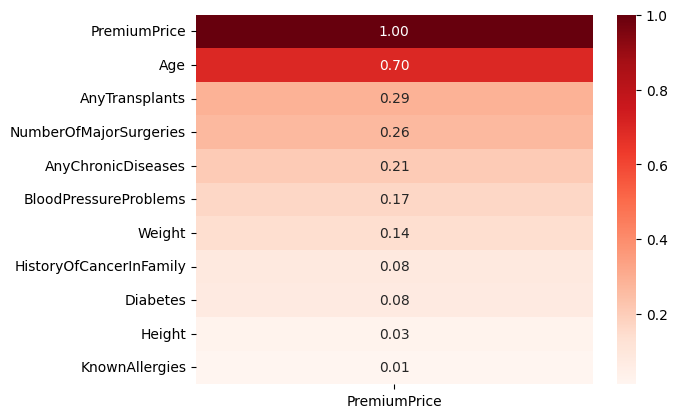

In [28]:
# filter the correlation with premium price only
sns.heatmap(df.corr()[['PremiumPrice']].sort_values(by = "PremiumPrice", ascending = False),
           annot = True, fmt = '0.2f', cmap = 'Reds')

In [29]:
# univarient Analysis
# Count the number person who are paying different premium
df['PremiumPrice'].value_counts()

PremiumPrice
23000    249
15000    202
28000    132
25000    103
29000     72
30000     47
35000     41
38000     34
31000     31
21000     26
19000     15
26000      7
39000      5
24000      4
32000      4
16000      3
18000      2
34000      2
36000      2
22000      1
40000      1
20000      1
27000      1
17000      1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='PremiumPrice'>

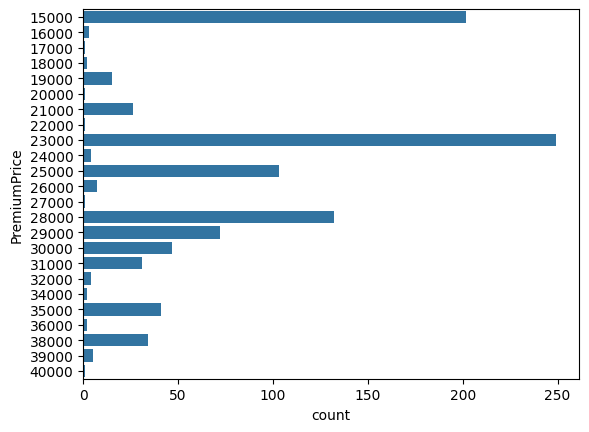

In [30]:
sns.countplot(y = df['PremiumPrice'])

<Axes: xlabel='PremiumPrice', ylabel='Count'>

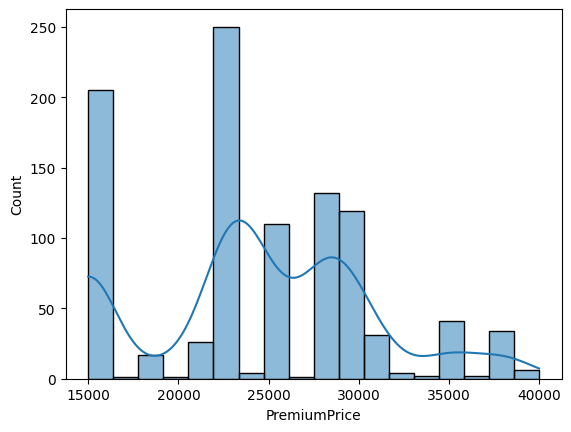

In [31]:
sns.histplot(df['PremiumPrice'], kde = True)

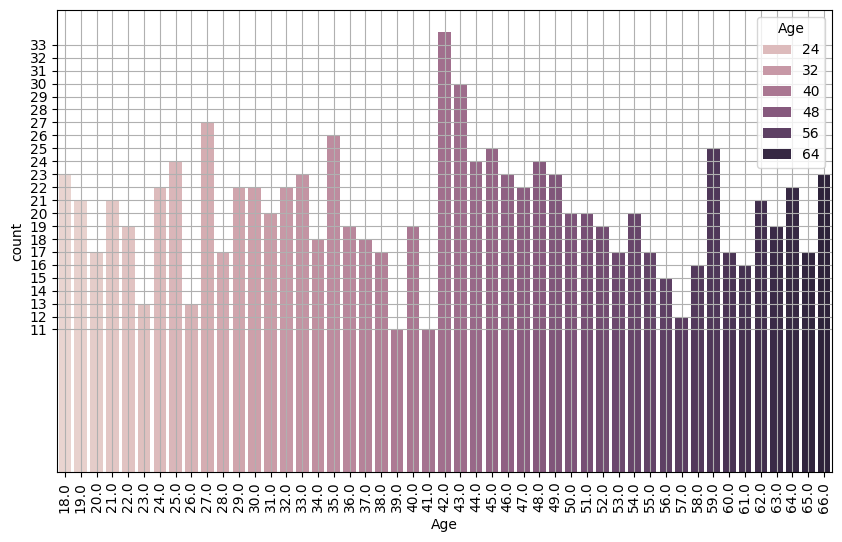

In [32]:
plt.figure(figsize = (10,6))
sns.countplot(x = df['Age'], hue= df['Age'],)
plt.xticks(rotation = 90)
plt.yticks(range(11,34))
plt.grid()
plt.show()

## Bivariant Analysis
#### graph on two variables

<Axes: xlabel='Age', ylabel='PremiumPrice'>

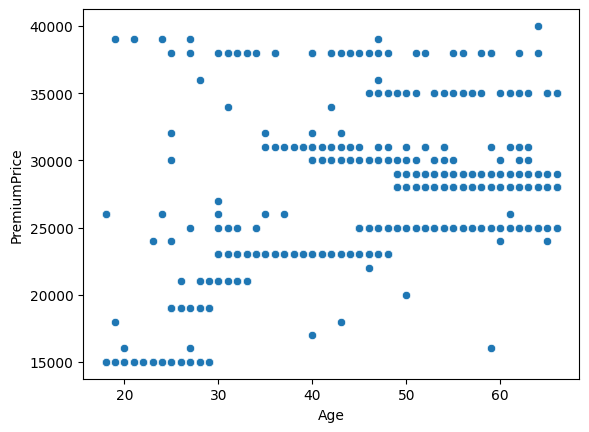

In [33]:
# plot the scatter plot to check the relation between age and premium price
sns.scatterplot(x = df['Age'], y = df['PremiumPrice'])

<Axes: xlabel='NumberOfMajorSurgeries', ylabel='PremiumPrice'>

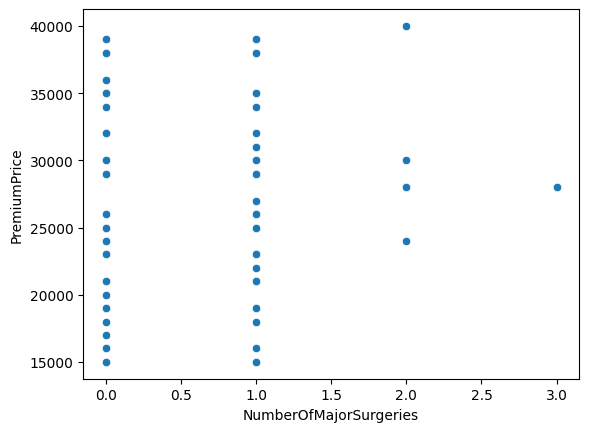

In [34]:
# plot the scatter plot to check the relation between number of surgeries  and premium price
sns.scatterplot(x = df['NumberOfMajorSurgeries'], y = df['PremiumPrice'])

<Axes: xlabel='BloodPressureProblems', ylabel='PremiumPrice'>

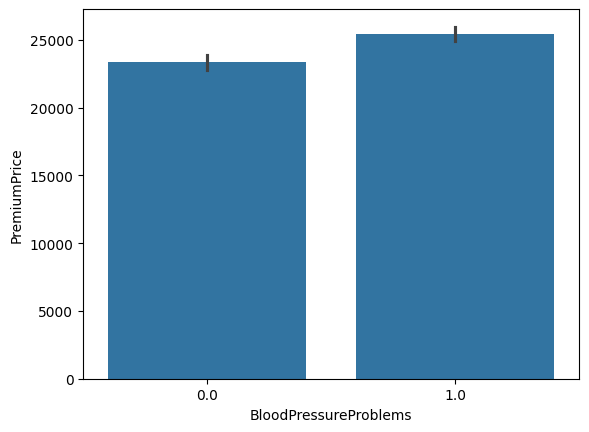

In [35]:
# Plot the graph between BloodPressure and PremiumPrice
sns.barplot(x = df['BloodPressureProblems'], y = df['PremiumPrice'])

<Axes: xlabel='Diabetes', ylabel='PremiumPrice'>

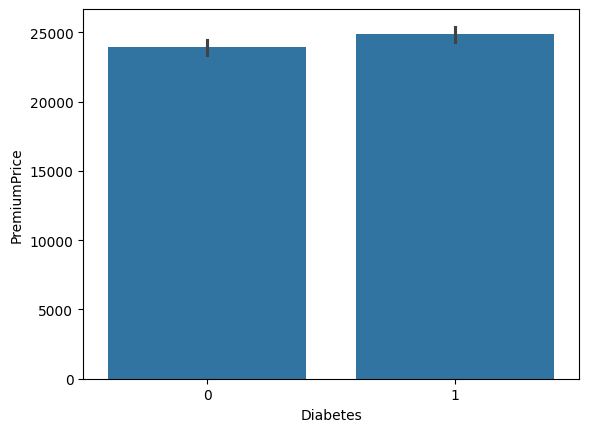

In [36]:
sns.barplot(x = df['Diabetes'], y = df['PremiumPrice'])

<Axes: xlabel='NumberOfMajorSurgeries', ylabel='PremiumPrice'>

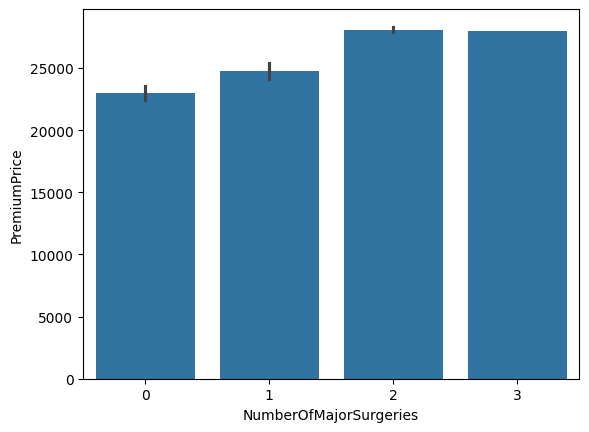

In [37]:
sns.barplot(x = df['NumberOfMajorSurgeries'], y = df['PremiumPrice'])

<Axes: ylabel='Age'>

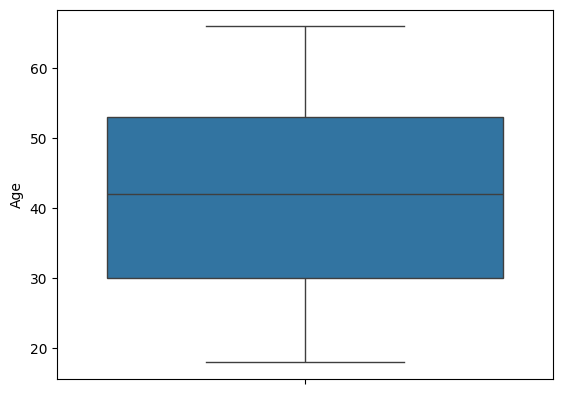

In [38]:
# plot boxplot to check the anomalies in some features
sns.boxplot(df['Age'])

<Axes: ylabel='Height'>

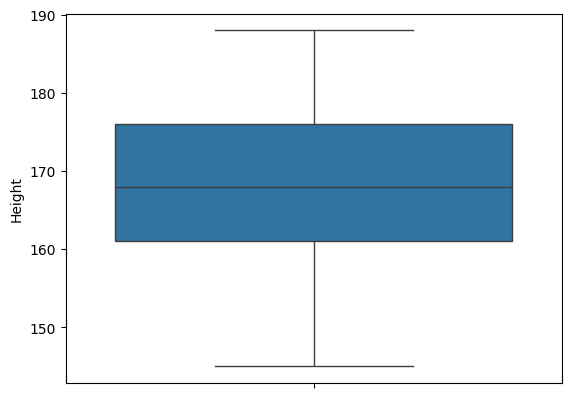

In [39]:
sns.boxplot(df['Height'])

<Axes: ylabel='Weight'>

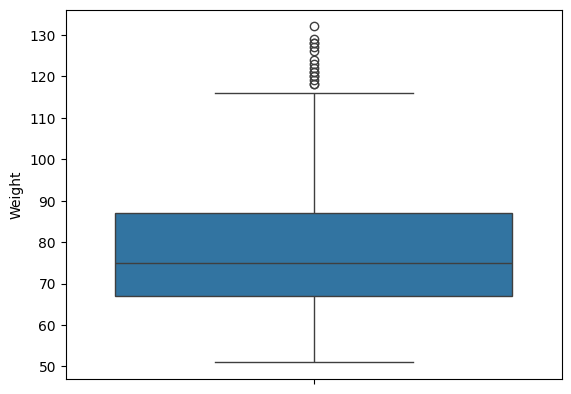

In [40]:
sns.boxplot(df['Weight'])

<Axes: ylabel='PremiumPrice'>

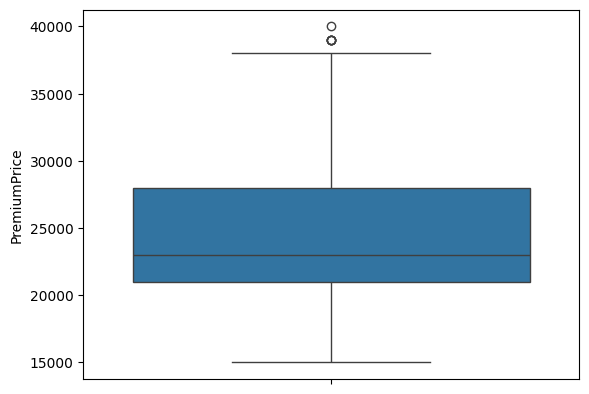

In [41]:
sns.boxplot(df['PremiumPrice'])

In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,986.0,41.752535,13.963245,18.0,30.0,42.0,53.0,66.0
Diabetes,986.0,0.419878,0.493789,0.0,0.0,0.0,1.0,1.0
BloodPressureProblems,986.0,0.465517,0.499063,0.0,0.0,0.0,1.0,1.0
AnyTransplants,986.0,0.055781,0.229615,0.0,0.0,0.0,0.0,1.0
AnyChronicDiseases,986.0,0.180527,0.384821,0.0,0.0,0.0,0.0,1.0
Height,986.0,168.182556,10.098155,145.0,161.0,168.0,176.0,188.0
Weight,986.0,76.950304,14.265096,51.0,67.0,75.0,87.0,132.0
KnownAllergies,986.0,0.215010,0.411038,0.0,0.0,0.0,0.0,1.0
HistoryOfCancerInFamily,986.0,0.117647,0.322353,0.0,0.0,0.0,0.0,1.0
NumberOfMajorSurgeries,986.0,0.667343,0.749205,0.0,0.0,1.0,1.0,3.0


<Axes: xlabel='Age', ylabel='PremiumPrice'>

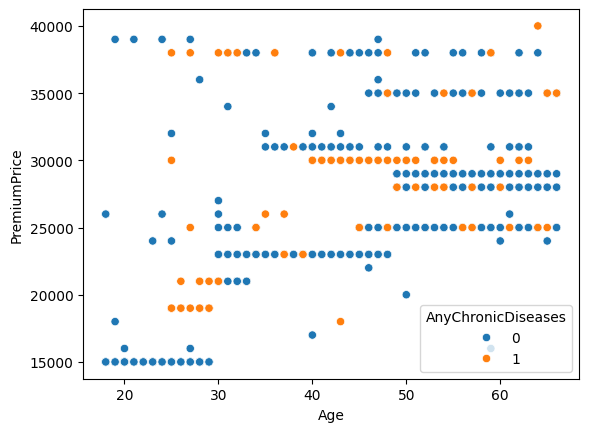

In [43]:
sns.scatterplot(x = df['Age'], y = df['PremiumPrice'], hue = df['AnyChronicDiseases'])

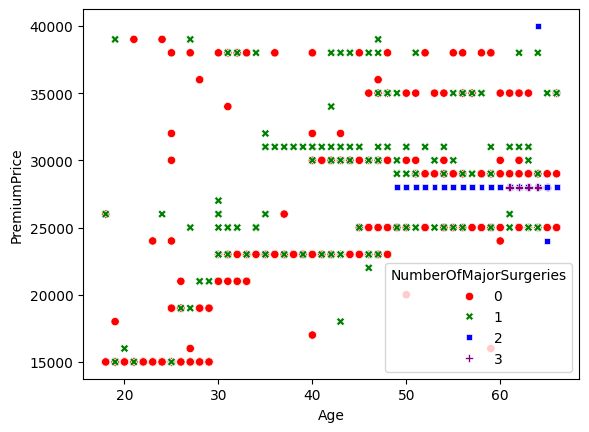

In [46]:
sns.scatterplot(x = df['Age'], y = df['PremiumPrice'], hue = df['NumberOfMajorSurgeries'],
               # size= df['NumberOfMajorSurgeries'],
               style= df['NumberOfMajorSurgeries'],
                palette = {0: 'red', 1: 'green', 2: 'blue', 3: 'purple', 4: 'orange'})
plt.show()

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      986 non-null    float64
 1   Diabetes                 986 non-null    int64  
 2   BloodPressureProblems    986 non-null    float64
 3   AnyTransplants           986 non-null    int64  
 4   AnyChronicDiseases       986 non-null    int64  
 5   Height                   986 non-null    int64  
 6   Weight                   986 non-null    int64  
 7   KnownAllergies           986 non-null    int64  
 8   HistoryOfCancerInFamily  986 non-null    int64  
 9   NumberOfMajorSurgeries   986 non-null    int64  
 10  PremiumPrice             986 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 84.9 KB


In [48]:
# Divide the data into independent (x) and Dependent(y)
x = df.drop('PremiumPrice', axis = 1)
x.head(5)

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries
0,45.0,0,0.0,0,0,155,57,0,0,0
1,60.0,1,0.0,0,0,180,73,0,0,0
2,36.0,1,1.0,0,0,158,59,0,0,1
3,52.0,1,1.0,0,1,183,93,0,0,2
4,38.0,0,0.0,0,1,166,88,0,0,1


In [49]:
y = df['PremiumPrice']
y.head(5)

0    25000
1    29000
2    23000
3    28000
4    23000
Name: PremiumPrice, dtype: int64

In [50]:
 # Now split the data into train and test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=5)

In [51]:
# Now check the shape of split data
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(788, 10) (198, 10)
(788,) (198,)


# import the linear Regression Model

In [53]:
from sklearn.linear_model import LinearRegression
# Creation of object of Model
lr_model = LinearRegression()

In [54]:
# Training of model
lr_model.fit(x_train, y_train)

LinearRegression()

In [55]:
# y = mx+c
# c -- Intercept
lr_model.intercept_

np.float64(5275.237639152521)

In [56]:
# y = mx + c
# m -- Coeficinet
lr_model.coef_

array([ 3.23789181e+02, -5.24557808e+02,  3.16954400e+02,  8.64685296e+03,
        2.59509424e+03, -4.51489899e+00,  7.36658360e+01,  1.99730901e+02,
        2.40559230e+03, -6.49123720e+02])

In [58]:
y_pred = lr_model.predict(x_test)
y_pred

array([26710.48525463, 22860.64254933, 27249.17425056, 21063.51843627,
       17803.2736817 , 18592.51640065, 22964.98858906, 19641.69746696,
       20889.66565498, 28235.5394672 , 29226.21466591, 26307.40525315,
       30607.17528714, 30498.18868809, 27648.26126223, 29936.88776185,
       23937.81751121, 19941.78452026, 26483.51061739, 38648.99924266,
       16146.48131396, 22037.49380858, 24752.68089402, 24889.5651627 ,
       31415.31922756, 29481.44022324, 23409.05397554, 26996.65912346,
       28838.11616478, 28867.52427423, 30397.56485647, 18913.57637613,
       21006.7404265 , 27589.98513351, 21283.1255165 , 24409.24753489,
       17137.12643328, 25723.81240983, 28200.23037709, 37254.41393628,
       19481.05546631, 15748.50765509, 21599.84671439, 21709.91662568,
       22615.43855145, 19546.67694309, 23466.9043035 , 18884.66492891,
       29466.5363001 , 27488.39833159, 24586.34825977, 29189.32032864,
       30216.60556602, 22429.93059534, 22774.96897245, 21063.59873935,
      

In [59]:
len(y_pred)

198

In [57]:
x_test.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries
935,38.0,0,1.0,0,1,170,71,0,1,1
176,42.0,0,0.0,0,0,176,71,1,0,1
629,42.0,0,0.0,0,1,172,89,0,0,0
739,25.0,0,1.0,0,0,170,84,1,1,1
300,26.0,1,0.0,0,0,181,74,0,0,0


In [ ]:
df.loc[371]

In [60]:
np.mean(abs(y_test - y_pred)) # MAE


np.float64(2579.206830828225)

# Model Evaluation

In [61]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [62]:
def model_eve(model_name, y_test, y_pred):
    print(f'{model_name} R2_score', r2_score(y_test, y_pred))
    print(f'{model_name}, MAE ',mean_absolute_error(y_test, y_pred))
    print(f'{model_name}, MSE ',mean_squared_error(y_test, y_pred))
    print(f'{model_name}, RMSE ',root_mean_squared_error(y_test, y_pred))

In [63]:
model_eve('lr_model', y_test, y_pred)

lr_model R2_score 0.6794608496489137
lr_model, MAE  2579.206830828225
lr_model, MSE  11233072.29534995
lr_model, RMSE  3351.577583071881


# Now find the best value of random State

In [65]:
mae = []
mse = []
rsme = []
r2score = []

for i in range(0,100):
    x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.05, random_state=i)
    lr_model.fit(x_train, y_train)
    y_pred = lr_model.predict(x_test)
    mae.append(mean_absolute_error(y_test, y_pred))
    mse.append(mean_squared_error(y_test, y_pred))
    rsme.append(root_mean_squared_error(y_test, y_pred))
    r2score.append(r2_score(y_test, y_pred))


In [66]:
print('R2',r2score.index(max(r2score)))
print('MAE',mae.index(min(mae)))
print('MSE',mse.index(min(mse)))
print('RSME',rsme.index(min(rsme)))


R2 4
MAE 65
MSE 65
RSME 65


############################################################################################

# Best value of random state for best accuracy

In [ ]:
# random_state = 4

In [67]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.05, random_state=4)

from sklearn.linear_model import LinearRegression
# Creation of object of Model
best_model = LinearRegression()


# Training of model
best_model.fit(x_train, y_train)

LinearRegression()

In [68]:
best_y_pred = best_model.predict(x_test)
len(best_y_pred)

50

In [69]:
model_eve('Best_model', y_test, best_y_pred)

Best_model R2_score 0.8110373026678976
Best_model, MAE  2380.862852807128
Best_model, MSE  9316314.488946246
Best_model, RMSE  3052.2638301670854


In [71]:
df.iloc[10,0:-1]

Age                         60.0
Diabetes                     0.0
BloodPressureProblems        NaN
AnyTransplants               0.0
AnyChronicDiseases           0.0
Height                     175.0
Weight                      74.0
KnownAllergies               0.0
HistoryOfCancerInFamily      0.0
NumberOfMajorSurgeries       2.0
Name: 10, dtype: float64

In [72]:
df.iloc[10]

Age                           60.0
Diabetes                       0.0
BloodPressureProblems          NaN
AnyTransplants                 0.0
AnyChronicDiseases             0.0
Height                       175.0
Weight                        74.0
KnownAllergies                 0.0
HistoryOfCancerInFamily        0.0
NumberOfMajorSurgeries         2.0
PremiumPrice               28000.0
Name: 10, dtype: float64

In [75]:
best_model.predict([df.iloc[541,0:-1]])

C:\Users\Dilip\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([28625.04289445])

In [76]:
df.iloc[541]

Age                           59.0
Diabetes                       1.0
BloodPressureProblems          0.0
AnyTransplants                 0.0
AnyChronicDiseases             0.0
Height                       176.0
Weight                        75.0
KnownAllergies                 0.0
HistoryOfCancerInFamily        0.0
NumberOfMajorSurgeries         0.0
PremiumPrice               29000.0
Name: 541, dtype: float64

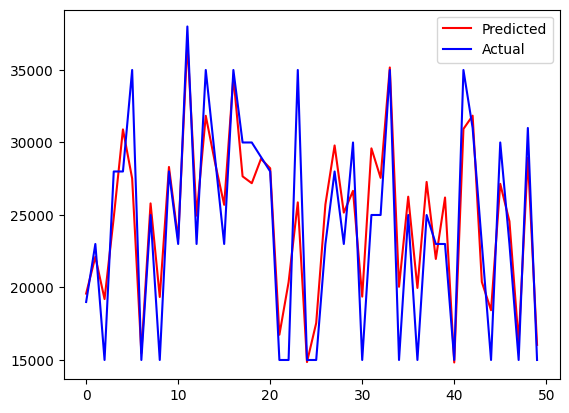

In [77]:
plt.plot(range(50),best_y_pred, c = 'r', label = 'Predicted')
plt.plot(range(50),y_test, c = 'b',label = 'Actual')
plt.legend()
plt.show()

In [64]:
# to convert the csv file into excel file
import pandas as pd
df = pd.read_csv('Medicalpremium1.csv')
df.to_excel('test.xlsx')